**Diabetes Risk Prediction**  
This notebook cleans the data to prepare it for our model that predicts Low /Moderate / High diabetes risk.

**Step 1: Import Libraries**

In [26]:
## Import the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from imblearn.over_sampling import SMOTE

print("Libraries loaded!")

Libraries loaded!


**Step 2: Import Data File**

In [27]:
# The dataset is loaded directly from our Github repository, so no one has to upload the file from a local drive.

url = "https://raw.githubusercontent.com/cano-elda/Midterm-Diabetes-Risk-Prediction-Group-3-ITAI-1371/refs/heads/main/data/diabetes_risk.csv"
df = pd.read_csv(url)
print("Data loaded!")


Data loaded!


**Step 3: Initial Analysis of Data**

In [28]:
# Print rows and columns

print("Rows and columns", df.shape)
display(df.head(10))
df.info()
display(df.isnull().sum())
display(df.describe())
display(df["diabetes_risk"].value_counts())


Rows and columns (6870, 19)


,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
1,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low
2,6,58,Male,Hyderabad,22.0,No,Active,Non-Vegetarian,Never,Occasional,6.9,6,148,6.3,148,100,98.0,High,Low
3,7,42,Female,Hyderabad,22.5,No,Sedentary,Non-Vegetarian,NaN,NaN,7.0,10,190,7.5,140,81,95.0,High,Moderate
4,8,42,Female,Delhi,19.5,No,Active,Non-Vegetarian,Never,Never,6.0,7,270,8.9,136,80,89.9,Middle,High
5,12,38,Female,Hyderabad,23.3,No,Active,Vegetarian,Never,Never,6.0,6,158,6.1,132,70,94.8,Low,Low
6,14,22,Male,Ahmedabad,19.3,Yes,Active,Non-Vegetarian,Never,Never,7.0,9,94,5.1,130,90,92.9,High,Low
7,15,26,Male,Ahmedabad,15.0,Yes,Active,Non-Vegetarian,Never,Occasional,8.9,1,119,6.3,118,79,84.5,Low,Low
8,17,46,Male,Ahmedabad,19.6,No,Sedentary,Vegetarian,Never,NaN,6.5,6,115,5.9,151,83,92.3,High,Low
9,18,49,Male,Ahmedabad,21.7,Yes,Moderate,Non-Vegetarian,Current,Never,9.0,6,167,7.0,140,80,100.2,Middle,Low


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6870 entries, 0 to 6869
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                6870 non-null   int64  
 1   age                       6870 non-null   int64  
 2   gender                    6870 non-null   object 
 3   city                      6870 non-null   object 
 4   bmi                       6870 non-null   float64
 5   family_history_diabetes   6870 non-null   object 
 6   physical_activity_level   6870 non-null   object 
 7   diet_type                 6870 non-null   object 
 8   smoking_status            6649 non-null   object 
 9   alcohol_consumption       5115 non-null   object 
 10  hours_sleep_per_night     6870 non-null   float64
 11  stress_level              6870 non-null   int64  
 12  fasting_blood_sugar       6870 non-null   int64  
 13  hba1c_level               6870 non-null   float64
 14  blood_pr

,0
patient_id,0
age,0
gender,0
city,0
bmi,0
family_history_diabetes,0
physical_activity_level,0
diet_type,0
smoking_status,221
alcohol_consumption,1755


,patient_id,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm
count,6870.000000,6870.000000,6870.000000,6870.000000,6870.000000,6870.000000,6870.000000,6870.000000,6870.000000,6870.000000
mean,7466.273654,44.487482,23.096492,7.246172,6.327802,170.345706,6.907496,140.296361,86.641921,100.321718
std,4318.835234,10.328696,4.048809,1.111986,2.090881,38.532605,0.846888,12.633844,8.292347,10.749903
min,4.000000,18.000000,15.000000,3.000000,1.000000,72.000000,4.900000,90.000000,50.000000,73.200000
25%,3779.250000,38.000000,20.200000,6.500000,5.000000,147.000000,6.400000,130.000000,80.000000,92.500000
50%,7457.500000,45.000000,22.700000,7.000000,6.000000,167.000000,6.800000,140.000000,88.000000,99.500000
75%,11188.500000,52.000000,25.600000,8.000000,8.000000,190.000000,7.400000,150.000000,90.000000,107.000000
max,14999.000000,75.000000,39.200000,12.000000,10.000000,400.000000,13.400000,184.000000,120.000000,147.400000


,count
diabetes_risk,
Low,4033
Moderate,1751
High,1086


**Step 4: Split Data: 70% Training / 30% Testing**

In [29]:
# Split data into 70% training and 30% testing

train, test = train_test_split(df, test_size=0.3, random_state=42, stratify=df["diabetes_risk"])
train = train.copy()
test = test.copy()

print("Training set:", train.shape)
print("Testing set:", test.shape)
print("Training classes:", train["diabetes_risk"].value_counts().to_dict())
print("Testing classes: ", test["diabetes_risk"].value_counts().to_dict())
train.head()



Training set: (4809, 19)
Testing set: (2061, 19)
Training classes: {'Low': 2823, 'Moderate': 1226, 'High': 760}
Testing classes:  {'Low': 1210, 'Moderate': 525, 'High': 326}


,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
6150,13387,59,Male,Chennai,27.3,Yes,Sedentary,Vegetarian,Never,Never,8.0,8,304,9.3,150,76,112.9,High,High
2927,6402,42,Female,Delhi,22.1,No,Active,Non-Vegetarian,Never,Never,6.9,7,111,6.1,150,91,96.2,High,Low
5296,11480,36,Female,Bengaluru,19.5,Yes,Sedentary,Non-Vegetarian,Former,NaN,8.0,5,117,5.8,121,82,87.1,High,Low
437,919,53,Female,Bengaluru,16.2,No,Active,Non-Vegetarian,Never,NaN,8.2,7,179,7.3,160,94,82.6,Low,Low
1341,2867,54,Female,Hyderabad,21.1,No,Moderate,Non-Vegetarian,Former,Never,9.5,4,147,6.7,152,90,96.1,NaN,Low


**Step 5: Basic Cleaning**  

This step removes the "patient_id" column because it does not any value to the dataset or to results we are looking for. It also removes 2 impossible rows. Since we split the data before any clean up we have to do it to the training and testing set but this does not create any leak into the testing set.

In [30]:
# Remove the patient_id column and 2 impossible rows.

for data in [train, test]:
  data.drop(columns=["patient_id"], inplace=True)

print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())

bad_train = train["blood_pressure_diastolic"] >= train["blood_pressure_systolic"]
bad_test = test["blood_pressure_diastolic"] >= test["blood_pressure_systolic"]
print("Bad rows in train:", bad_train.sum())
print("Bad rows in test:", bad_test.sum())

train = train[~(bad_train)]
test = test[~(bad_test)]

print("Training set after cleaning:", train.shape)
print("Testing set after cleaning:", test.shape)


Duplicate rows in train: 0
Duplicate rows in test: 0
Bad rows in train: 2
Bad rows in test: 0
Training set after cleaning: (4807, 18)
Testing set after cleaning: (2061, 18)


**Step 6: EDA Charts on Training Data Before Processing**

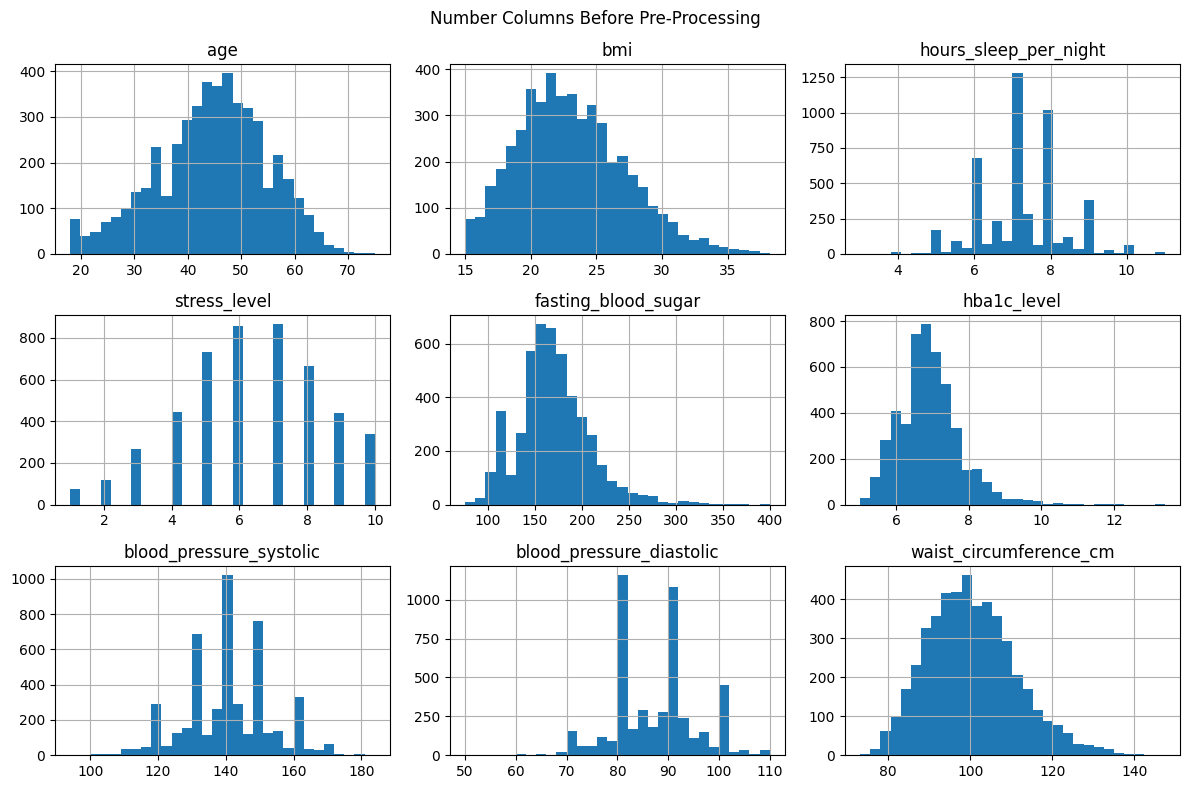

age                        -0.307296
bmi                         0.491386
hours_sleep_per_night       0.076439
stress_level               -0.221471
fasting_blood_sugar         0.929281
hba1c_level                 0.957686
blood_pressure_systolic    -0.011257
blood_pressure_diastolic    0.073561
waist_circumference_cm      0.487015
dtype: float64


In [31]:
# Charts before Data Was Processed

train.hist(figsize=(12, 8), bins=30)
plt.suptitle("Number Columns Before Pre-Processing")
plt.tight_layout()
plt.show()
print(train.skew(numeric_only=True))


This is a histogram of all the columns or features in the dataset before processing. As noticed some of the features have negative values, this mean they are skewed and will need to be looked at to see if they need to be fix.

**Step 7: Fill Nan and Null Values**

In [32]:
# Fill in empty columns

missing_before = train.isnull().sum()

fill_cols = ["smoking_status", "alcohol_consumption", "income_bracket"]
nan_rows = train[train[fill_cols].isnull().any(axis=1)].index[:5]
print("BEFORE filling (sample rows with missing values):")
display(train.loc[nan_rows, fill_cols])

smoke_mode = train["smoking_status"].mode()[0]
income_mode = train["income_bracket"].mode()[0]
print("Smoking mode:", smoke_mode, " Income mode:", income_mode)

for data in [train, test]:
  data["smoking_status"] = data["smoking_status"].fillna(smoke_mode)
  data["income_bracket"] = data["income_bracket"].fillna(income_mode)
  data["alcohol_consumption"] = data["alcohol_consumption"].fillna("Unknown")

print("AFTER filling (the same rows):")
display(train.loc[nan_rows, fill_cols])

print("Missing values left in train:", train.isnull().sum().sum())
print("Missing values left in test:", test.isnull().sum().sum())

BEFORE filling (sample rows with missing values):


,smoking_status,alcohol_consumption,income_bracket
5296,Former,NaN,High
437,Never,NaN,Low
1341,Former,Never,NaN
4946,Current,NaN,Middle
5802,NaN,Never,Low


Smoking mode: Never  Income mode: Middle
AFTER filling (the same rows):


,smoking_status,alcohol_consumption,income_bracket
5296,Former,Unknown,High
437,Never,Unknown,Low
1341,Former,Never,Middle
4946,Current,Unknown,Middle
5802,Never,Never,Low


Missing values left in train: 0
Missing values left in test: 0


**Before/After Chart**

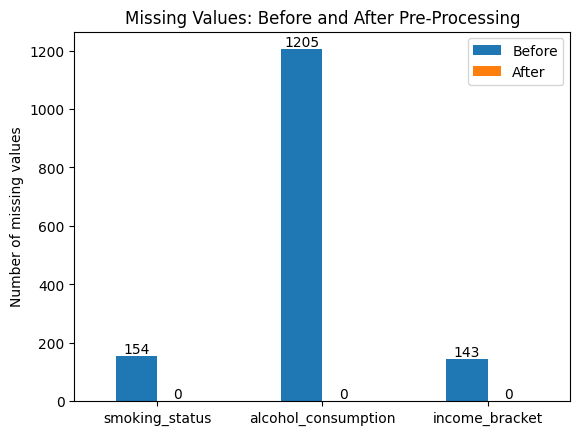

In [33]:
# Chart Showing The Changes

compare = pd.DataFrame({"Before": missing_before, "After": train.isnull().sum()})
compare = compare[compare["Before"] > 0]
ax = compare.plot(kind="bar")
for bars in ax.containers:
    ax.bar_label(bars)
plt.title("Missing Values: Before and After Pre-Processing")
plt.ylabel("Number of missing values")
plt.xticks(rotation=0)
plt.show()

**Blood Sugar Rises**

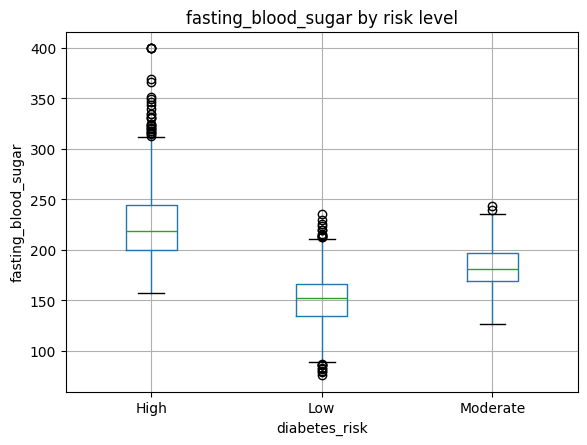

In [34]:
for col in ["fasting_blood_sugar"]:
    train.boxplot(column=col, by="diabetes_risk")
    plt.title(col + " by risk level")
    plt.suptitle("")
    plt.ylabel(col)
    plt.show()

**HBA1C Level**

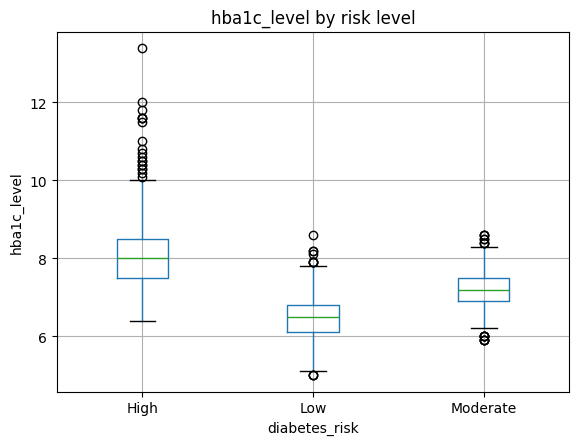

In [35]:
for col in ["hba1c_level"]:
    train.boxplot(column=col, by="diabetes_risk")
    plt.title(col + " by risk level")
    plt.suptitle("")
    plt.ylabel(col)
    plt.show()

Fasting blood sugar and HbA1c increase from low to high risk so they are considered strong predictors.

**Step 7.5: Feature Engineering**

 5 new columns from the existing ones to give the model more useful information.

In [36]:
print("Columns before:", train.shape[1])

for data in [train, test]:
    data["mean_arterial_pressure"] = data["blood_pressure_diastolic"] + (data["blood_pressure_systolic"] - data["blood_pressure_diastolic"]) / 3
    data["glucose_hba1c_interaction"] = data["fasting_blood_sugar"] * data["hba1c_level"]
    data["bmi_category"] = (data["bmi"] >= 18.5).astype(int) + (data["bmi"] >= 25).astype(int) + (data["bmi"] >= 30).astype(int)
    data["age_group"] = (data["age"] >= 30).astype(int) + (data["age"] >= 45).astype(int) + (data["age"] >= 60).astype(int)
    data["high_blood_pressure"] = ((data["blood_pressure_systolic"] >= 140) & (data["blood_pressure_diastolic"] >= 90)).astype(int)

print("Columns after:", train.shape[1])
train[["mean_arterial_pressure", "glucose_hba1c_interaction", "bmi_category", "age_group", "high_blood_pressure"]].head(10)

Columns before: 18
Columns after: 23


,mean_arterial_pressure,glucose_hba1c_interaction,bmi_category,age_group,high_blood_pressure
6150,100.666667,2827.2,2,2,0
2927,110.666667,677.1,1,1,1
5296,95.000000,678.6,1,1,0
437,116.000000,1306.7,0,2,1
1341,110.666667,984.9,1,2,1
362,116.666667,583.0,1,1,1
343,108.000000,1072.5,1,2,0
4398,100.000000,1014.0,1,2,0
2391,94.000000,1552.2,1,1,0
3213,99.333333,684.4,1,2,0


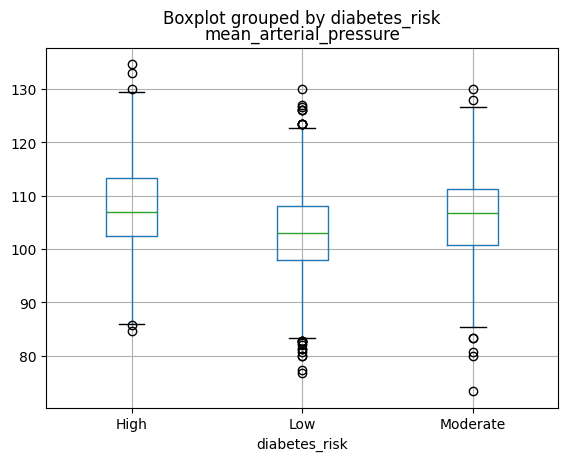

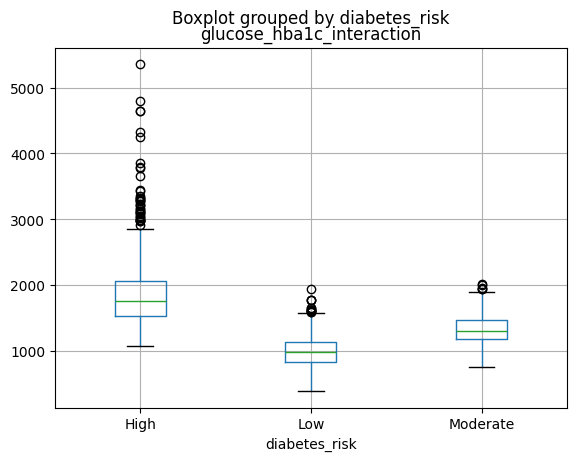

In [37]:
train.boxplot(column="mean_arterial_pressure", by="diabetes_risk")
plt.show()

train.boxplot(column="glucose_hba1c_interaction", by="diabetes_risk")
plt.show()

**Step 8: Encoding Ordinal and Binary Categorical Features**

Some categorical features, which have a natural order or contain two possible values, are converted into numerical values.

In [38]:
# Encode binary and ordinal categorical features

family_map = {
    "No": 0,
    "Yes": 1
}

activity_map = {
    "Sedentary": 0,
    "Moderate": 1,
    "Active": 2
}

income_map = {
    "Low": 0,
    "Middle": 1,
    "High": 2
}

risk_map = {
    "Low": 0,
    "Moderate": 1,
    "High": 2
}

for data in [train, test]:
    data["family_history_diabetes"] = data["family_history_diabetes"].map(family_map)
    data["physical_activity_level"] = data["physical_activity_level"].map(activity_map)
    data["income_bracket"] = data["income_bracket"].map(income_map)
    data["diabetes_risk"] = data["diabetes_risk"].map(risk_map)

print("Encoded training data:")
print(train[["family_history_diabetes",
             "physical_activity_level",
             "income_bracket",
             "diabetes_risk"]].head(10))

Encoded training data:
      family_history_diabetes  physical_activity_level  income_bracket  \
6150                        1                        0               2   
2927                        0                        2               2   
5296                        1                        0               2   
437                         0                        2               0   
1341                        0                        1               1   
362                         0                        1               2   
343                         1                        0               2   
4398                        0                        1               2   
2391                        0                        0               1   
3213                        0                        2               1   

      diabetes_risk  
6150              2  
2927              0  
5296              0  
437               0  
1341              0  
362               0  
343     

**Step 9: One-Hot Encoding**

Categorical features without a natural order are converted using one-hot encoding, to create separate 0/1 columns for each category.

In [39]:
# One-hot encode categorical features without natural order

one_hot_columns = [
    "gender",
    "city",
    "diet_type",
    "smoking_status",
    "alcohol_consumption"
]

train = pd.get_dummies(
    train,
    columns=one_hot_columns,
    dtype=int
)

test = pd.get_dummies(
    test,
    columns=one_hot_columns,
    dtype=int
)

# Make sure train and test have the same feature columns
train, test = train.align(
    test,
    join="left",
    axis=1,
    fill_value=0
)

print("Training shape after one-hot encoding:", train.shape)
print("Testing shape after one-hot encoding:", test.shape)

train.head()

Training shape after one-hot encoding: (4807, 38)
Testing shape after one-hot encoding: (2061, 38)


,age,bmi,family_history_diabetes,physical_activity_level,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,...,diet_type_Pescatarian,diet_type_Vegan,diet_type_Vegetarian,smoking_status_Current,smoking_status_Former,smoking_status_Never,alcohol_consumption_Never,alcohol_consumption_Occasional,alcohol_consumption_Regular,alcohol_consumption_Unknown
6150,59,27.3,1,0,8.0,8,304,9.3,150,76,...,0,0,1,0,0,1,1,0,0,0
2927,42,22.1,0,2,6.9,7,111,6.1,150,91,...,0,0,0,0,0,1,1,0,0,0
5296,36,19.5,1,0,8.0,5,117,5.8,121,82,...,0,0,0,0,1,0,0,0,0,1
437,53,16.2,0,2,8.2,7,179,7.3,160,94,...,0,0,0,0,0,1,0,0,0,1
1341,54,21.1,0,1,9.5,4,147,6.7,152,90,...,0,0,0,0,1,0,1,0,0,0


In [40]:
print("Remaining non-numeric columns:",
      train.select_dtypes(exclude=np.number).columns.tolist())

Remaining non-numeric columns: []


**Step 10: Normalization of Skewed Numerical Features**

The skewness analysis showed that fasting blood sugar and HbA1c level were positively skewed.

In [41]:
# Normalize skewed numerical features

normalize_columns = [
    "fasting_blood_sugar",
    "hba1c_level"
]

# Save original values for before/after comparison
before_normalization = train[normalize_columns].copy()

# Fit PowerTransformer only on training data
power_transformer = PowerTransformer(method="yeo-johnson")

train[normalize_columns] = power_transformer.fit_transform(
    train[normalize_columns]
)

# Apply the same transformation to test data
test[normalize_columns] = power_transformer.transform(
    test[normalize_columns]
)

print("Skewness before normalization:")
print(before_normalization.skew())

print("\nSkewness after normalization:")
print(train[normalize_columns].skew())

Skewness before normalization:
fasting_blood_sugar    0.929281
hba1c_level            0.957686
dtype: float64

Skewness after normalization:
fasting_blood_sugar    0.000673
hba1c_level           -0.012800
dtype: float64


**Before/After Chart**

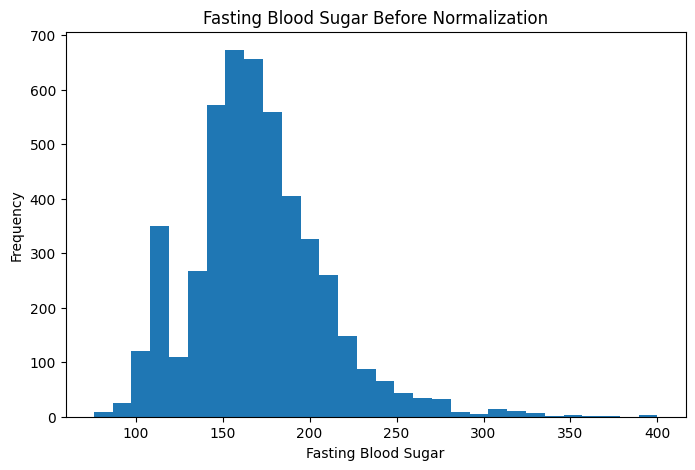

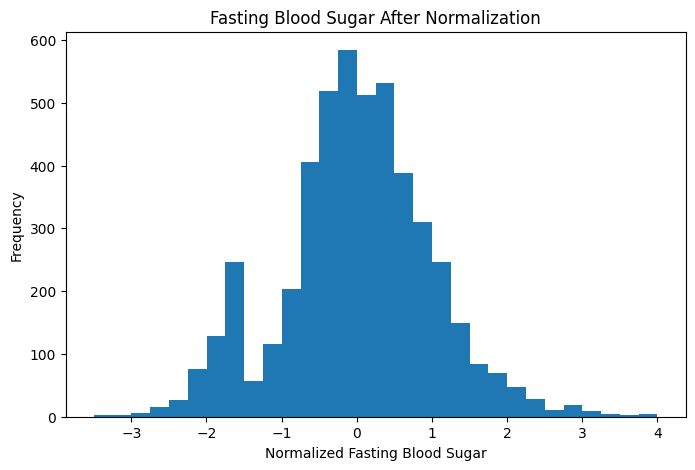

In [42]:
plt.figure(figsize=(8, 5))
plt.hist(before_normalization["fasting_blood_sugar"], bins=30)
plt.title("Fasting Blood Sugar Before Normalization")
plt.xlabel("Fasting Blood Sugar")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(train["fasting_blood_sugar"], bins=30)
plt.title("Fasting Blood Sugar After Normalization")
plt.xlabel("Normalized Fasting Blood Sugar")
plt.ylabel("Frequency")
plt.show()

**Step 11: Min-Max Scaling**

Min-Max scaling transforms selected numerical features to a range between 0 and 1 so that features with larger values do not dominate the model.

In [43]:
# Numerical columns to scale

scale_columns = [
    "age",
    "bmi",
    "hours_sleep_per_night",
    "stress_level",
    "fasting_blood_sugar",
    "hba1c_level",
    "blood_pressure_systolic",
    "blood_pressure_diastolic",
    "waist_circumference_cm"
]

# Save values before scaling for comparison
before_scaling = train[scale_columns].copy()

# Fit the scaler ONLY on training data
scaler = MinMaxScaler()

train[scale_columns] = scaler.fit_transform(train[scale_columns])

# Apply the same scaler to test data
test[scale_columns] = scaler.transform(test[scale_columns])

print("Sample training data after Min-Max scaling:")
print(train[scale_columns].head())

print("\nMinimum values in training data:")
print(train[scale_columns].min())

print("\nMaximum values in training data:")
print(train[scale_columns].max())

Sample training data after Min-Max scaling:
           age       bmi  hours_sleep_per_night  stress_level  \
6150  0.719298  0.530172                 0.6250      0.777778   
2927  0.421053  0.306034                 0.4875      0.666667   
5296  0.315789  0.193966                 0.6250      0.444444   
437   0.614035  0.051724                 0.6500      0.666667   
1341  0.631579  0.262931                 0.8125      0.333333   

      fasting_blood_sugar  hba1c_level  blood_pressure_systolic  \
6150             0.832232     0.736709                 0.622222   
2927             0.224623     0.283892                 0.622222   
5296             0.256021     0.216603                 0.300000   
437              0.511103     0.499450                 0.733333   
1341             0.392633     0.401044                 0.644444   

      blood_pressure_diastolic  waist_circumference_cm  
6150                  0.433333                0.535040  
2927                  0.683333                0.

**Before/After Chart**

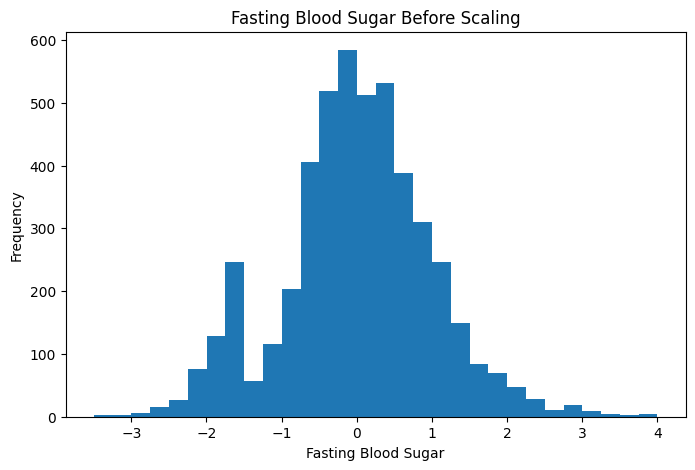

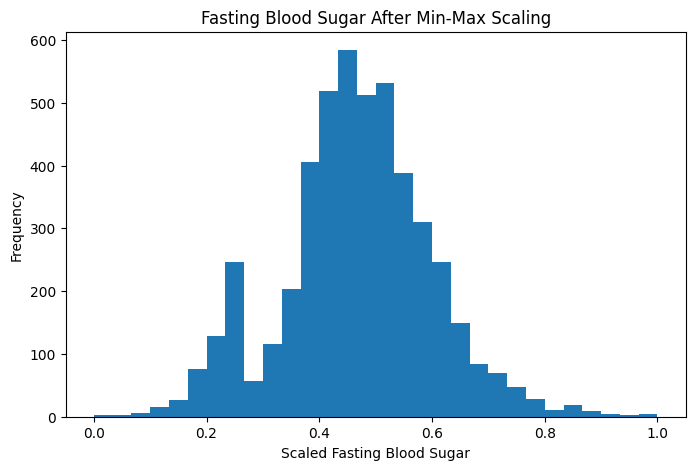

In [44]:
plt.figure(figsize=(8, 5))
plt.hist(before_scaling["fasting_blood_sugar"], bins=30)
plt.title("Fasting Blood Sugar Before Scaling")
plt.xlabel("Fasting Blood Sugar")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(train["fasting_blood_sugar"], bins=30)
plt.title("Fasting Blood Sugar After Min-Max Scaling")
plt.xlabel("Scaled Fasting Blood Sugar")
plt.ylabel("Frequency")
plt.show()

**Step 12: Class Balancing**

In [45]:
   new_num_cols = ["mean_arterial_pressure", "glucose_hba1c_interaction"]

   new_scaler = MinMaxScaler()
   train[new_num_cols] = new_scaler.fit_transform(train[new_num_cols])
   test[new_num_cols] = new_scaler.transform(test[new_num_cols])

   print(train[new_num_cols].min())
   print(train[new_num_cols].max())

mean_arterial_pressure       0.0
glucose_hba1c_interaction    0.0
dtype: float64
mean_arterial_pressure       1.0
glucose_hba1c_interaction    1.0
dtype: float64


In [46]:
from imblearn.over_sampling import SMOTENC

X_train = train.drop(columns=["diabetes_risk"])
y_train = train["diabetes_risk"]
X_test = test[X_train.columns]
y_test = test["diabetes_risk"]

print("Before:", y_train.value_counts().sort_index().to_dict())

is_category = [col not in scale_columns + new_num_cols for col in X_train.columns]
X_train_bal, y_train_bal = SMOTENC(categorical_features=is_category, random_state=42).fit_resample(X_train, y_train)

print("After: ", y_train_bal.value_counts().sort_index().to_dict())

import numpy as np
rng = np.random.default_rng(42)
for prefix in ["gender_", "city_", "diet_type_", "smoking_status_", "alcohol_consumption_"]:
    cols = [c for c in X_train.columns if c.startswith(prefix)]
    empty = X_train_bal[cols].sum(axis=1) == 0
    share = X_train[cols].mean().values
    picks = rng.choice(len(cols), size=int(empty.sum()), p=share / share.sum())
    X_train_bal.loc[empty, cols] = np.eye(len(cols), dtype=int)[picks]

Before: {0: 2821, 1: 1226, 2: 760}
After:  {0: 2821, 1: 2821, 2: 2821}


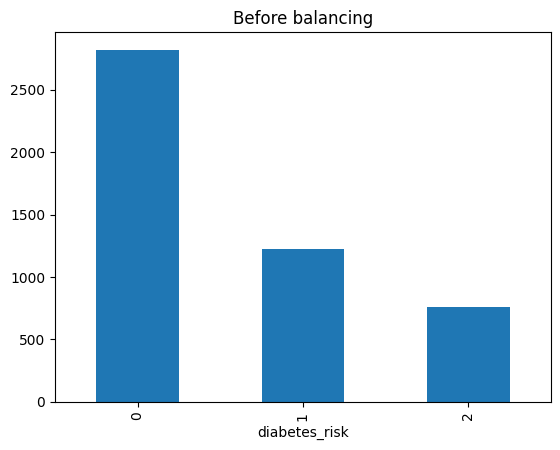

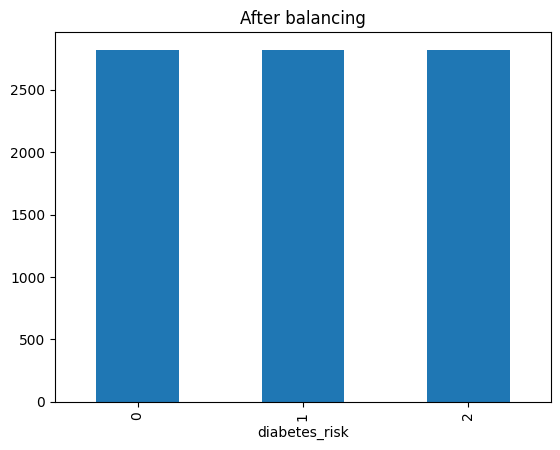

,age,bmi,family_history_diabetes,physical_activity_level,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,...,diet_type_Pescatarian,diet_type_Vegan,diet_type_Vegetarian,smoking_status_Current,smoking_status_Former,smoking_status_Never,alcohol_consumption_Never,alcohol_consumption_Occasional,alcohol_consumption_Regular,alcohol_consumption_Unknown
0,0.719298,0.530172,1,0,0.6250,0.777778,0.832232,0.736709,0.622222,0.433333,...,0,0,1,0,0,1,1,0,0,0
1,0.421053,0.306034,0,2,0.4875,0.666667,0.224623,0.283892,0.622222,0.683333,...,0,0,0,0,0,1,1,0,0,0
2,0.315789,0.193966,1,0,0.6250,0.444444,0.256021,0.216603,0.300000,0.533333,...,0,0,0,0,1,0,0,0,0,1
3,0.614035,0.051724,0,2,0.6500,0.666667,0.511103,0.499450,0.733333,0.733333,...,0,0,0,0,0,1,0,0,0,1
4,0.631579,0.262931,0,1,0.8125,0.333333,0.392633,0.401044,0.644444,0.666667,...,0,0,0,0,1,0,1,0,0,0


In [47]:
y_train.value_counts().sort_index().plot(kind="bar", title="Before balancing")
plt.show()

y_train_bal.value_counts().sort_index().plot(kind="bar", title="After balancing")
plt.show()

X_train_bal.head()

**Step 13: Save the Clean Data**

In [48]:
import os
os.makedirs("data", exist_ok=True)

train_clean = X_train_bal.copy()
train_clean["diabetes_risk"] = y_train_bal.values

test_clean = X_test.copy()
test_clean["diabetes_risk"] = y_test.values

train_clean.to_csv("data/diabetes_train_clean.csv", index=False)
test_clean.to_csv("data/diabetes_test_clean.csv", index=False)

print("Train:", train_clean.shape, "| Test:", test_clean.shape)
print("Missing values:", train_clean.isnull().sum().sum(), test_clean.isnull().sum().sum())
train_clean.head()

Train: (8463, 38) | Test: (2061, 38)
Missing values: 0 0


,age,bmi,family_history_diabetes,physical_activity_level,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,...,diet_type_Vegan,diet_type_Vegetarian,smoking_status_Current,smoking_status_Former,smoking_status_Never,alcohol_consumption_Never,alcohol_consumption_Occasional,alcohol_consumption_Regular,alcohol_consumption_Unknown,diabetes_risk
0,0.719298,0.530172,1,0,0.6250,0.777778,0.832232,0.736709,0.622222,0.433333,...,0,1,0,0,1,1,0,0,0,2
1,0.421053,0.306034,0,2,0.4875,0.666667,0.224623,0.283892,0.622222,0.683333,...,0,0,0,0,1,1,0,0,0,0
2,0.315789,0.193966,1,0,0.6250,0.444444,0.256021,0.216603,0.300000,0.533333,...,0,0,0,1,0,0,0,0,1,0
3,0.614035,0.051724,0,2,0.6500,0.666667,0.511103,0.499450,0.733333,0.733333,...,0,0,0,0,1,0,0,0,1,0
4,0.631579,0.262931,0,1,0.8125,0.333333,0.392633,0.401044,0.644444,0.666667,...,0,0,0,1,0,1,0,0,0,0


**Step 14: Using This Dataset for ML**

This dataset can be used to predict if a patient has Low, Moderate or High diabetes risk. This is a classification problem. For the final, we plan to try logistic regression, random forest and gradient boosting. We will check how well each one does with recall and F1-score, not just accuracy, because missing a High risk patient is the worst mistake.

In [49]:
from google.colab import files
files.download("data/diabetes_train_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>